Na poprzednich zajęciach:
- **tokenizacja** – podział tekstu na słowa / tokeny,
- **spaCy Matcher** – znajdowanie wzorców na podstawie części mowy i cech morfologicznych.

# Wektory słów


## Tokenizacja a wektory słów

Tokenizacja -> Podziel tekst na kawałki (ID ze słownika)

Embedding -> Przedstaw każde słowo w postaci liczb, aby algorytm mógł z nim dalej pracować

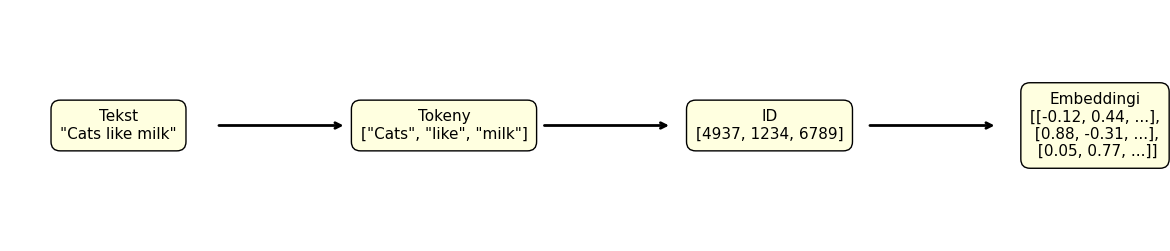

Komputer nie „rozumie” tekstu, tylko operuje na liczbach.
Zatem każde słowo (np. „król”, „kot”, „miłość”) trzeba jakoś zamienić na liczby, żeby można było nim manipulować w modelu.

Najprostszy pomysł — **one-hot encoding**


```
słownik = [kot, król, królowa]
"król" → [0, 1, 0]
```

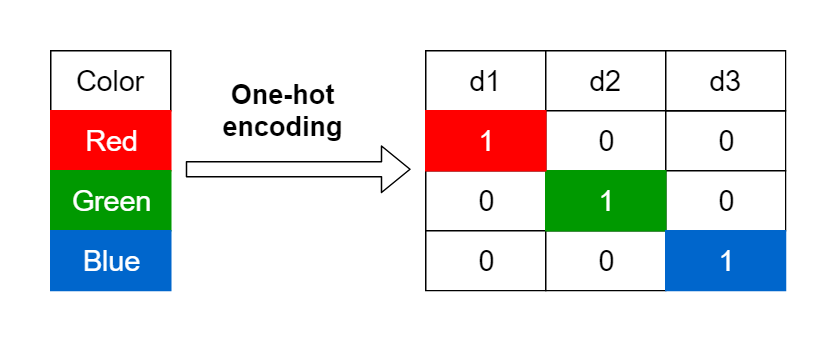



Dlaczego one-hot encoding jest problematyczny?

❌  Bardzo duży wymiar - Jeśli mamy słownik np. 100 000 słów, każdy wektor ma długość 100 000 — to ogromne marnotrawstwo pamięci.

❌ Brak informacji o znaczeniu - Wszystkie wektory są od siebie tak samo odległe — np. “kot” i “pies” są tak samo różne jak “kot” i “samolot”.
Nie ma żadnego pojęcia o podobieństwie semantycznym (znaczeniowym).

❌ Brak możliwości uogólniania - Model nie może „zrozumieć”, że pewne słowa mają podobne znaczenie — każde słowo jest całkowicie niezależne.

```
słownik = [kot, król, królowa]
"kot" → [1, 0, 0]
"król" → [0, 1, 0]
"królowa" → [0, 0, 1]
```

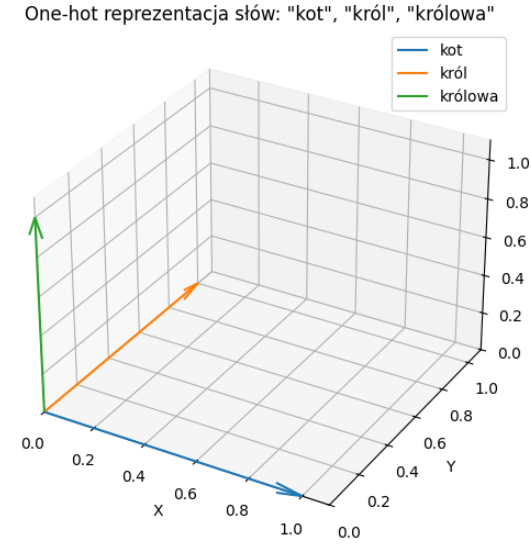

Widzimy, że każdy wektor idzie w swoją stronę, każdy jest tak samo odległy od siebie (90 stopni). Żadne dwa nie są do siebie bliżej ani dalej — odległość między każdym z nich jest taka sama.

W naszym przykładzie: kot, król i królowa są tak samo podobni i różni = nie ma wartości semantycznej.

## Embedingi
Embeddingi rozwiązują ten problem. W embeddingach uczymy model, żeby słowa, które występują w podobnych kontekstach, miały **podobne wektory**.

Dwa wektory są podobne, kiedy wskazują w podobnym kierunku w przestrzeni wielowymiarowej.
Czyli: jeśli narysujesz te wektory jako strzałki zaczynające się w tym samym punkcie (np. w punkcie (0,0,0)) to mają **mały kąt między sobą**.

Przykład:
```
"king" → [0.25, 0.88, -0.12, 0.40, ...]
"queen" → [0.22, 0.90, -0.10, 0.45, ...]
"cat" → [-0.70, 0.11, 0.45, 0.20, ...]
```


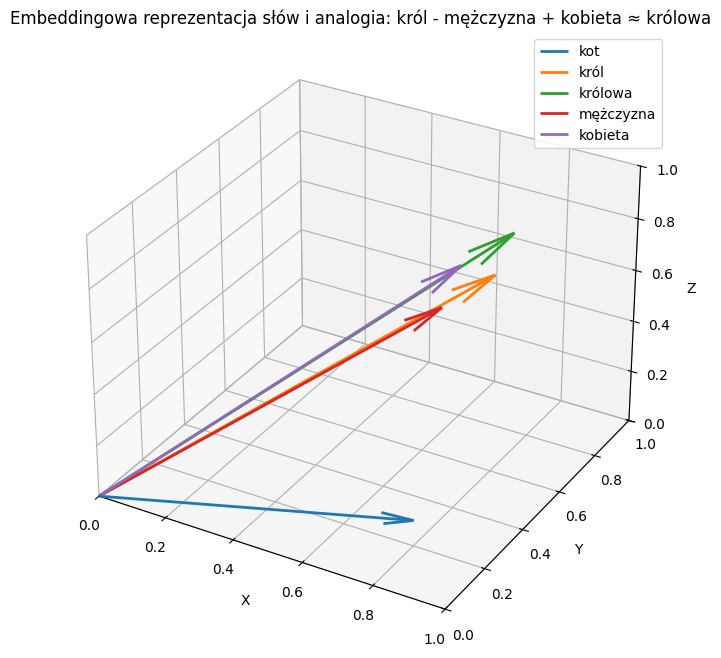


```
król − mężczyzna + kobieta ≈ królowa
```



Teraz punkty w przestrzeni układają się tak, że słowa o podobnym znaczeniu są blisko siebie.
To jest właśnie **semantyczne podobieństwo** —
podobieństwo w sensie znaczenia, a nie liter czy indeksów w tabeli.

## Cosinusowe podobieństwo — jak mierzymy „bliskość znaczeń”

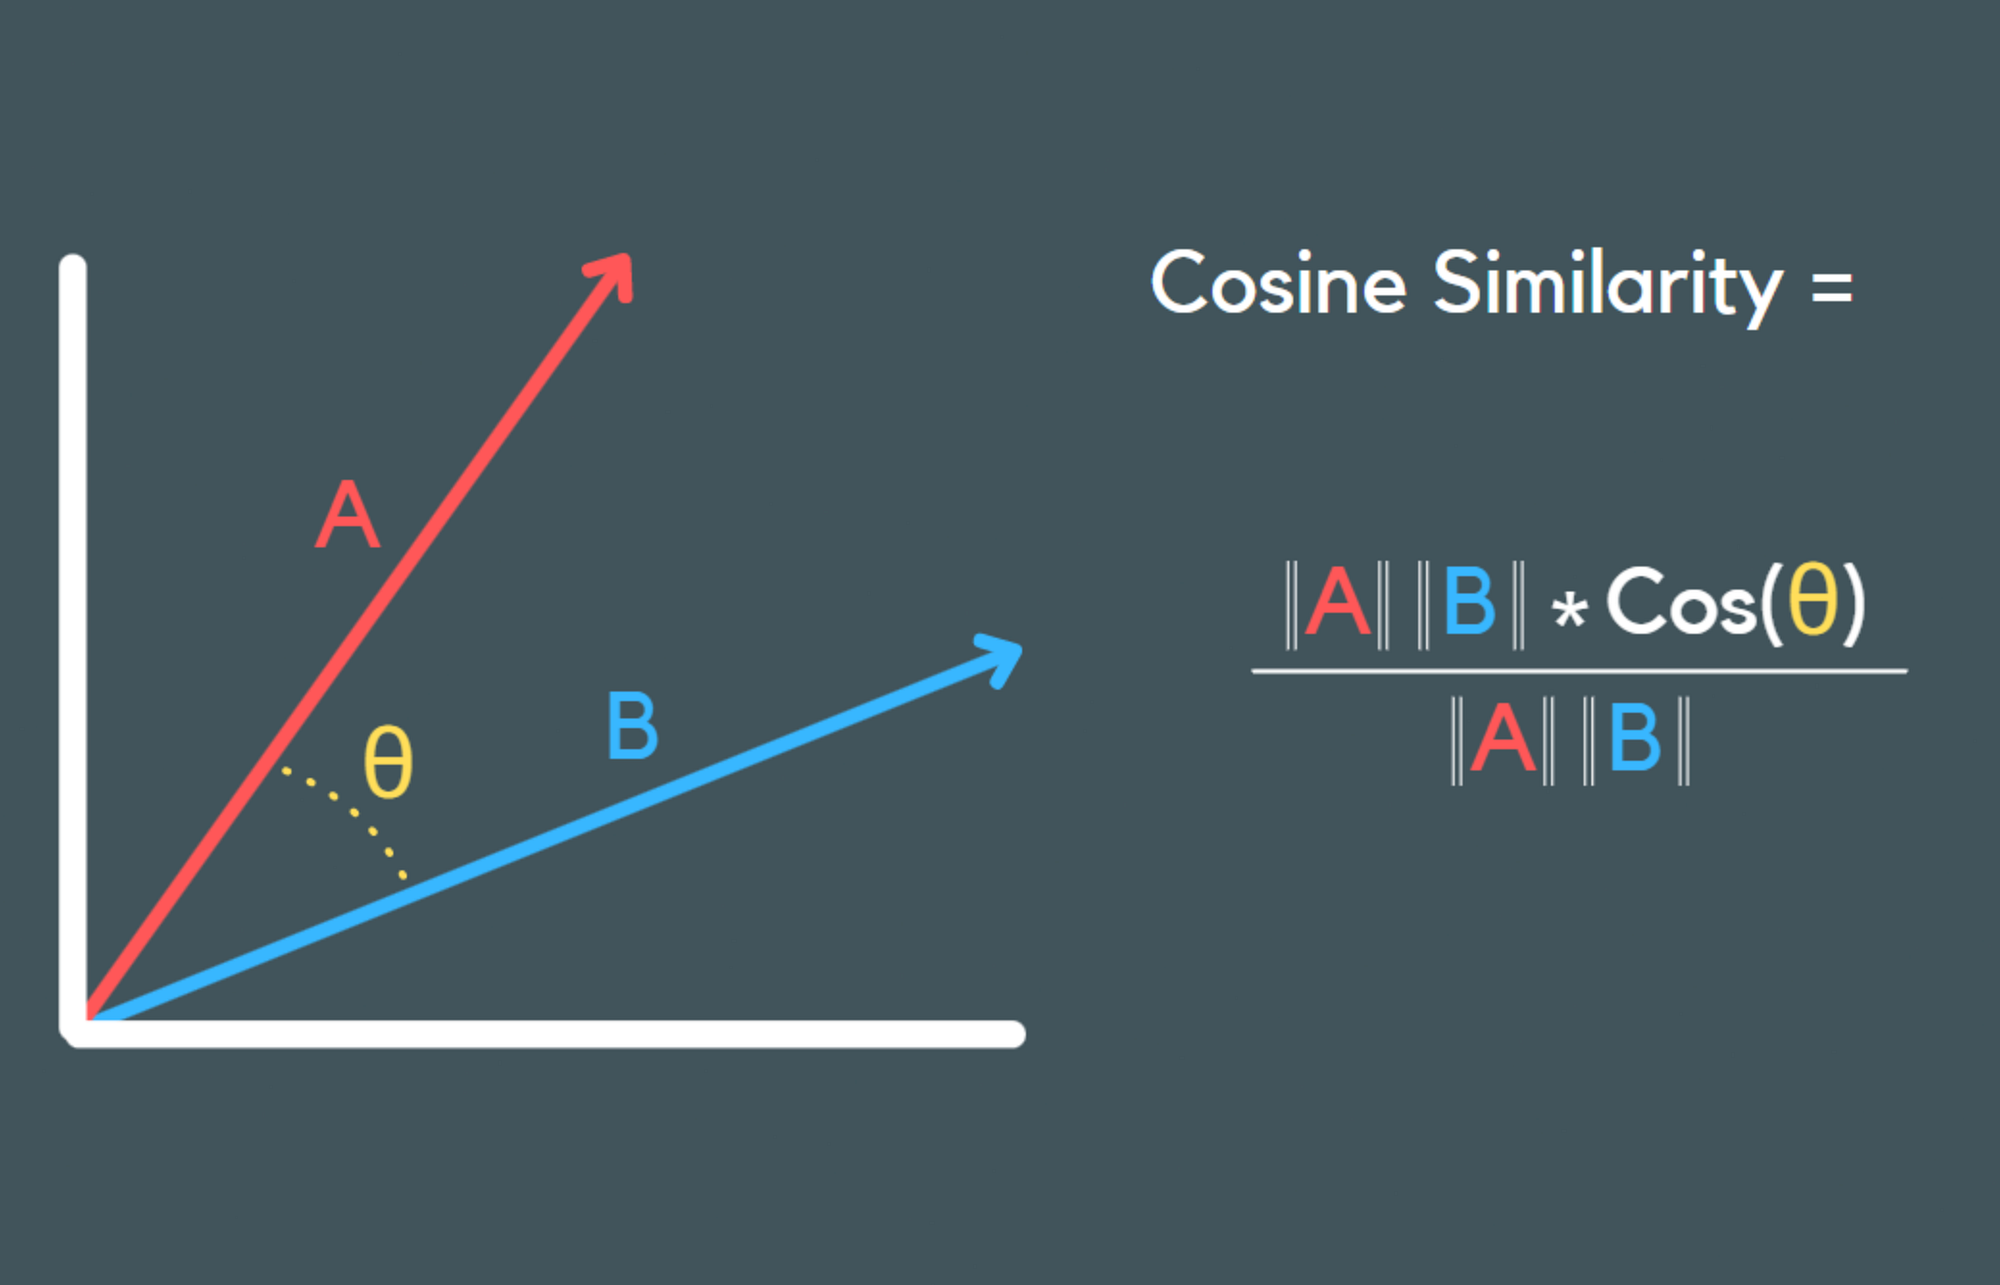

Cosinusowe podobieństwo to sposób na sprawdzenie, czy dwa wektory są „w tym samym kierunku”:

*  1 → bardzo podobne (np. „kot” i „pies”)
*  0 → brak podobieństwa (np. „kot” i „okno”)
*  -1 → całkowite przeciwieństwo

Ważne: Patrzymy nie na długość wektorów, tylko na kąt między nimi.
Dwa wektory, które „patrzą” w tym samym kierunku, oznaczają słowa o podobnym znaczeniu.

Skąd się biorą te wektory?

Z treningu modelu językowego (np. Word2Vec, GloVe, FastText, BERT).
Model uczy się na dużych korpusach tekstu, obserwując konteksty słów.


Efekt:

„king” i „queen” często występują w podobnych zdaniach (np. royal palace, throne, reign) → mają podobne wektory.

„dog” i „cat” też → inna grupa semantyczna.

## Trochę praktyki

Zaczniemy od zapoznania się z bibloteką **gensim**
Jej nazwa pochodzi od "GENerate SIMilar" — bo jej głównym celem jest znajdowanie podobieństwa między dokumentami lub słowami.

Użyjemy klasy **KeyedVectors** - to strukturą danych  w gensim, która przechowuje wektory słów (embeddingi) wytrenowane dowolnym modelem. Czyli po prostu taki kontener do pracy z wektorami - niezależnie od tego, jak one zostały wytrenowane.

In [ ]:
!pip install gensim

In [2]:
import gensim
from gensim.models import KeyedVectors

weźmiemy sobie polskie pre-trenowane wektory: http://dsmodels.nlp.ipipan.waw.pl
pobieramy plik:

In [ ]:
!wget http://dsmodels.nlp.ipipan.waw.pl/dsmodels/nkjp+wiki-forms-restricted-300-skipg-ns.txt.gz --no-check-certificate

Rozpakowujemy dane

In [4]:
!gzip -d "nkjp+wiki-forms-restricted-300-skipg-ns.txt.gz"

Badamy format pliku

In [ ]:
!head -n 100 nkjp+wiki-forms-restricted-300-skipg-ns.txt
#Pierwsza linia - lość słów (1982479), rozmiar wektora(300)
#Każda kolejna linia - słowo, liczby reperezentujące wektor

(to może chwilę zająć)

In [6]:
#Ładowanie wektorów z pliku do naszego KeyedVectors
wv = KeyedVectors.load_word2vec_format('nkjp+wiki-forms-restricted-300-skipg-ns.txt')

In [ ]:
wv.key_to_index.keys()
wv['dom']

 Znajdziemy najbardziej podobne słowo do słowa kobieta.

In [ ]:
wv.most_similar('kobieta')

Znajdź najbardziej podobne słowo do słowa "kobieta", które nie jest podobne do słowa "mężczyzna"

In [ ]:
wv.most_similar(positive=['kobieta'], negative=['mężczyzna'])

W grupie "pies kot żubr budyń" znajdź słowo, które nie pasuje.

In [ ]:
wv.doesnt_match(['pies', 'kot', 'żubr', 'budyń'])

zbadaj podobieństwo między kotem a psem

In [ ]:
wv.similarity('kot', 'pies')

Teraz zajmiemy się podobieństwami pomiędzy zdaniami

Word mover distance to minimalna suma odległości, jaką trzeba „pokonać”, aby słowa z jednego zdania pokryły znaczeniowo słowa z drugiego zdania.

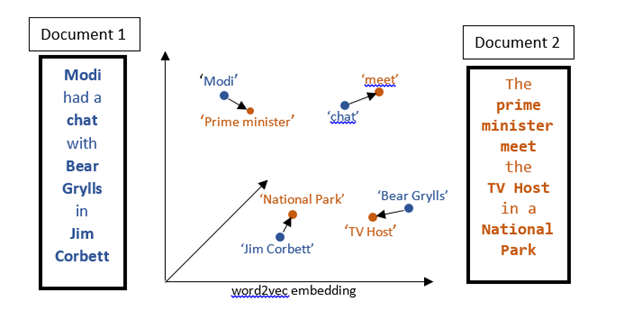

In [ ]:
!pip install POT #Po tej instalacji gensim może szybciej i dokładniej liczyć wmdistance

In [ ]:
sentence_1 = 'Byłem dzisiaj w kinie'.lower().split()
sentence_2 = 'Poszłam wczoraj do teatru'.lower().split()

In [ ]:
wv.wmdistance(sentence_1, sentence_2)


WMD nie jest ograniczone do 0-1, ale przy normalizacji embeddingów zwykle wartości mieszczą się w 0-4 dla krótkich zdań.

wynik ~1.25 sugeruje, że zdania są umiarkowanie podobne semantycznie.

Dla porównania:

* Dwa identyczne zdania → WMD ≈ 0

* Zupełnie różne zdania → WMD > 2.5-3

## Flair

Flair to biblioteka NLP od Zalando Research (Python)

**Główna idea:**

* Klasyczne embeddingi (Word2Vec, GloVe, FastText) dają stały wektor dla każdego słowa, niezależnie od kontekstu:

    *"bank"* w *"river bank"* i *"money bank"* → ten sam wektor.

* Flair tworzy kontekstowe embeddingi(wektor słowa zależy od jego zdania / kontekstu)

    więc "*bank*" w "*river bank*" będzie inny niż w "*money bank*".

Flair uczy się tego przez modele LSTM działające w dwóch kierunkach (forward i backward).

In [ ]:
!pip install flair

In [ ]:
from flair.embeddings import FlairEmbeddings, StackedEmbeddings
from flair.data import Sentence

In [ ]:
embeddings = FlairEmbeddings('news-forward')

#tworzymy objekty Sentence
s1 = Sentence("How does it feel to be a scribe?")
s2 = Sentence("There is no such thing as simply good or bad")
sentences = [s1, s2]


# Obliczamy embeddingi(zanurzamy słowa)
embeddings.embed(sentences)

for sentence in sentences: #Zanurzone zdania nadal są obiektem Sentence
  print(sentence)

In [ ]:
#dostajemy embeddingi poszczególnych słów
for sentence in sentences:
  for token in sentence:
    print(token.embedding)
#embeddingi są tensorami

In [ ]:
import numpy as np

In [ ]:
for sentence in sentences:
  for token in sentence:
    print(np.array(token.embedding))

Embeddingi dla zdań

In [ ]:
from flair.embeddings import DocumentPoolEmbeddings

In [ ]:
sentence_embeddings = DocumentPoolEmbeddings([FlairEmbeddings('news-forward')])

In [ ]:
sentence_embeddings.embed(sentences)

In [ ]:
for sentence in sentences:
  print(sentence.embedding)

# Zadania

###Zadanie1

Załaduj polski model kontekstowych embeddingów Flair:

In [ ]:
embeddings = FlairEmbeddings('pl-forward')

In [ ]:
s1 = Sentence("Zamek w Malborku jest bardzo stary.")
s2 = Sentence("Suwak w kurtce to zamek błyskawiczny")
s3 = Sentence("Sprawdź, czy zamek w drzwiach działa")
sentences = [s1, s2, s3]

Oblicz embeddingi dla wszystkich zdań:

In [ ]:
embeddings.embed(sentences)

Wypisz każde zdanie i dla słowa "zamek", wypisz pierwsze 5 wymiarów embeddingu:

In [ ]:
for sentence in sentences:
    #TODO

Czy embeddingi są różne w zależności od znaczenia słowa?

Odpowiedź: Tak

###Zadanie 2

Stwórz bota z bazą przykładownych pytań i odpowiedzi, zwracającego odpowiedź na zapytanie na podstawie podobieństwa (WMD albo flair document embeddings) pomiędzy zapytniem użytownika a pytaniami w swojej bazie

Przykład:

Zbiór pytań i odpowiedzi :

```
[
  {"q1" : "a1"},
  {"q2" : "a2"},
  {"q3" : "a3"},
  ...
  {"qn" : "an"},
]
```
Wektoryzujemy pytania:

```
  {"q1_vecotorized" : "a1"},
  {"q2_vecotorized" : "a2"},
  {"q3_vecotorized" : "a3"},
  ...
  {"qn_vecotorized" : "an"},
```
Dla pytania użytkownia pytania q_user wektoryzujemy je i liczmy podobieństwo z pytaniami w bazie


```
sim("q_user_vectorized","q1_vecotorized"), sim("q_user_vectorized","q2_vecotorized"), ... ("q_user_vectorized""qn_vecotorized")

```
Zwracamy odpowiedź do pytania z bazy najbardziej podobnego do pytania użytkownika
$$
argmax(sim(q_{user}vectorized,q_{i}vecotorized))
$$

Do liczenia podobnieństma można użyć np https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cosine.html ale wtedy robimy argmin bo
$$
cosine\ distance = 1 - cosine\ similarity
$$




In [ ]:
qa = [
  {"q": "Pytanie?", "a": "Odpowiedź."},
]

In [ ]:
# importy
from scipy.spatial.distance import cosine

def bot(user_question):
  # TODO

  print(f"Pytanie użytkownika: X")
  print(f"Najbardziej podobne pytanie z bazy danych: X")
  print(f"Odpowiedź: X")

def calculate_similarity(vec1, vec2):
    return 1 - cosine(vec1, vec2)

In [ ]:
# TODO - zadaj 3 pytania